## Problem Statement 

Manual resume screening is slow and inefficient—recruiters spend hours reviewing unqualified candidates.

### Challenge

Match a **candidate’s CV** with a **job description (JD)** and generate a clear, interpretable score.

### Solution

A simple ML-based system that:

* Uses **TF-IDF + Cosine Similarity** for overall match
* Uses **Regex** for skill matching
* Combines both into a **final score with grade & recommendation**


1. **Step 1 — Text Cleaning & Preprocessing**
2. **Step 2 — Skill Extraction via NLP**
3. **Step 3 — TF-IDF Vectorisation**
4. **Step 4 — Cosine Similarity**
5. **Step 5 — Skill Match Score**
6. **Step 6 — Composite Scoring & Grading**
7. **Step 7 — Skill Gap Report**
8. **Visualisations**



In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords',quiet = True)
nltk.download('punkt' , quiet = True)
STOP_WORDS = set(stopwords.words('english'))


In [2]:
import pandas as pd
df = pd.read_csv('job_descriptions.csv')
df.head()

,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."
2,481640072963533,0 to 12 Years,PhD,$61K-$104K,Macao,"Macao SAR, China",22.1987,113.5439,Temporary,84525,...,9687619505,Operations Manager,Quality Control Manager,Jobs2Careers,Quality Control Managers establish and enforce...,"{'Legal Assistance, Bonuses and Incentive Prog...",Quality control processes and methodologies St...,Establish and enforce quality control standard...,United Services Automobile Assn.,"{""Sector"":""Insurance"",""Industry"":""Insurance: P..."
3,688192671473044,4 to 11 Years,PhD,$65K-$91K,Porto-Novo,Benin,9.3077,2.3158,Full-Time,129896,...,+1-820-643-5431x47576,Network Engineer,Wireless Network Engineer,FlexJobs,"Wireless Network Engineers design, implement, ...","{'Transportation Benefits, Professional Develo...",Wireless network design and architecture Wi-Fi...,"Design, configure, and optimize wireless netwo...",Hess,"{""Sector"":""Energy"",""Industry"":""Mining, Crude-O..."
4,117057806156508,1 to 12 Years,MBA,$64K-$87K,Santiago,Chile,-35.6751,-71.5429,Intern,53944,...,343.975.4702x9340,Event Manager,Conference Manager,Jobs2Careers,A Conference Manager coordinates and manages c...,"{'Flexible Spending Accounts (FSAs), Relocatio...",Event planning Conference logistics Budget man...,Specialize in conference and convention planni...,Cairn Energy,"{""Sector"":""Energy"",""Industry"":""Energy - Oil & ..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615940 entries, 0 to 1615939
Data columns (total 23 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Job Id            1615940 non-null  int64  
 1   Experience        1615940 non-null  object 
 2   Qualifications    1615940 non-null  object 
 3   Salary Range      1615940 non-null  object 
 4   location          1615940 non-null  object 
 5   Country           1615940 non-null  object 
 6   latitude          1615940 non-null  float64
 7   longitude         1615940 non-null  float64
 8   Work Type         1615940 non-null  object 
 9   Company Size      1615940 non-null  int64  
 10  Job Posting Date  1615940 non-null  object 
 11  Preference        1615940 non-null  object 
 12  Contact Person    1615940 non-null  object 
 13  Contact           1615940 non-null  object 
 14  Job Title         1615940 non-null  object 
 15  Role              1615940 non-null  object 
 16  

In [4]:
df = df.sample(n = 2000, random_state = 42).reset_index(drop=True)
print(f"Dataset loaded! Total rows we are using: {len(df)}")
print(f"Columns available: {list(df.columns)}")

Dataset loaded! Total rows we are using: 2000
Columns available: ['Job Id', 'Experience', 'Qualifications', 'Salary Range', 'location', 'Country', 'latitude', 'longitude', 'Work Type', 'Company Size', 'Job Posting Date', 'Preference', 'Contact Person', 'Contact', 'Job Title', 'Role', 'Job Portal', 'Job Description', 'Benefits', 'skills', 'Responsibilities', 'Company', 'Company Profile']


In [5]:
df[['Job Title' , 'Role', 'Job Description', 'skills']].head(5)

,Job Title,Role,Job Description,skills
0,Procurement Manager,Supplier Diversity Manager,Promote diversity and inclusion in the supply ...,Supplier diversity programs Diversity and incl...
1,Architectural Designer,Architectural Drafter,Architectural Drafters assist architects and e...,Architectural drafting AutoCAD 2D and 3D model...
2,Art Teacher,Art Education Coordinator,An Art Education Coordinator plans and manages...,Art education curriculum Program development T...
3,Environmental Consultant,Environmental Impact Analyst,Environmental Impact Analysts assess the envir...,Environmental impact analysis Data collection ...
4,Art Teacher,Art Education Coordinator,An Art Education Coordinator plans and manages...,Art education curriculum Program development T...


In [6]:
print("Top 20 Job Roles in the dataset:")
print(df['Role'].value_counts().head(20))

Top 20 Job Roles in the dataset:
Role
Network Administrator             26
Interaction Designer              25
Backend Developer                 19
Procurement Analyst               18
Executive Assistant               17
Quality Assurance Analyst         17
User Interface Designer           17
Data Analyst                      17
Inventory Manager                 16
Residential Landscape Designer    14
IT Support Specialist             14
SEO Specialist                    14
Social Media Manager              14
Demand Planner                    13
Database Administrator            13
Frontend Developer                13
Retirement Planner                13
Business Intelligence Analyst     13
Procurement Manager               13
User Experience Designer          13
Name: count, dtype: int64


In [7]:
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower();
    text = re.sub(r'[^a-z0-9\s\+\#]','',text)
    text = re.sub(r'\s+','',text).strip()

    words = text.split()
    words = [w for w in words if w not in STOP_WORDS and len(w) > 1]

    return ''.join(words)
    

 


In [8]:

sample = "We are looking for a Python Developer with AWS and Docker experience!!"
print("Original:", sample)
print("Cleaned: ", clean_text(sample))

Original: We are looking for a Python Developer with AWS and Docker experience!!
Cleaned:  wearelookingforapythondeveloperwithawsanddockerexperience


In [9]:
print("Cleaning job descriptions...")
df['clean_jd'] = df['Job Description'].apply(clean_text)

print("Cleaning skills column...")
df['clean_skills'] = df['skills'].apply(clean_text)

# Combine both for better matching
df['jd_full'] = df['clean_jd'] + ' ' + df['clean_skills']

print("Cleaning done!")

Cleaning job descriptions...
Cleaning skills column...
Cleaning done!


In [10]:
SKILL_LIST = [
    # Programming
    'python', 'java', 'javascript', 'c++', 'c#', 'r', 'sql', 'scala', 'go', 'php',
    # Web
    'react', 'angular', 'nodejs', 'html', 'css', 'django', 'flask', 'rest',
    # Data & ML
    'machine learning', 'deep learning', 'nlp', 'tensorflow', 'pytorch',
    'scikit-learn', 'pandas', 'numpy', 'keras', 'data analysis', 'statistics',
    'tableau', 'powerbi', 'spark', 'data science',
    # Cloud & DevOps
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'linux', 'git', 'jenkins',
    # Databases
    'mysql', 'postgresql', 'mongodb', 'redis', 'oracle',
    # Soft Skills
    'communication', 'leadership', 'teamwork', 'agile', 'scrum', 'problem solving'
]

print(f"Total skills in our list: {len(SKILL_LIST)}")


Total skills in our list: 52


In [11]:
def extract_skills(text):

    text_lower = str(text).lower()
    found_skills = []

    for skill in SKILL_LIST:
        if re.search(r'\b' + re.escape(skill)+ r'\b' , text_lower):
            found_skills.append(skill)
    return found_skills     

In [12]:
test_resume = "I know Python, machine learning, TensorFlow, and AWS."
print("Resume:", test_resume)
print("Skills found:", extract_skills(test_resume))

Resume: I know Python, machine learning, TensorFlow, and AWS.
Skills found: ['python', 'machine learning', 'tensorflow', 'aws']


In [13]:

TARGET_ROLE = 'Web Development'

# Filter dataset for this role
role_jobs = df[df['Role'].str.contains(TARGET_ROLE, case=False, na=False)]

# If nothing found, try matching job title instead
if len(role_jobs) == 0:
    role_jobs = df[df['Job Title'].str.contains(TARGET_ROLE.split()[0], case=False, na=False)]

print(f"Found {len(role_jobs)} job postings for role: '{TARGET_ROLE}'")

# Combine all job descriptions for this role into one big text
master_jd = ' '.join(role_jobs['Job Description'].dropna().tolist())
master_jd_clean = clean_text(master_jd)

# Extract what skills this role requires
required_skills = extract_skills(master_jd)

print(f"\nSkills required for '{TARGET_ROLE}':")
print(required_skills)

Found 25 job postings for role: 'Web Development'

Skills required for 'Web Development':
['javascript', 'html', 'css', 'communication']


In [14]:
resumes = {
    "Alice": """
        I have 4 years of experience in Python, machine learning, and data science.
        I have worked with TensorFlow, PyTorch, scikit-learn, pandas, and numpy.
        Good knowledge of NLP and deep learning. Used AWS and Docker for deployment.
        I work well in teams, follow Agile methods, and have strong communication skills.
        I also know SQL and PostgreSQL for data storage.
    """,

    "Bob": """
        Full-stack web developer with 5 years experience.
        Expert in JavaScript, React, Angular, Node.js, HTML, CSS.
        Backend experience with Django and Flask. Familiar with REST APIs.
        Databases: MySQL, MongoDB, Redis. DevOps: Docker, Jenkins, Git.
        Strong problem solving and teamwork skills.
    """,

    "Carol": """
        Data analyst with 3 years of experience.
        Skills: Python, R, SQL, Tableau, Power BI, Excel.
        Worked on data analysis and reporting for finance and marketing.
        Strong statistics knowledge. Good communication and leadership.
        Some knowledge of pandas and numpy.
    """,

    "David": """
        Cloud and DevOps engineer with 6 years experience.
        AWS certified. Also worked with Azure and GCP.
        Expert in Docker, Kubernetes, Terraform, Linux, Jenkins.
        Strong Git and CI/CD pipeline experience.
        Good communication, agile practitioner.
    """,

    "Eva": """
        Fresher. Knows basic Python and Java from college.
        Did a small HTML and CSS project.
        Completed a machine learning online course.
        Good communication skills. Eager to learn.
    """
}

print(f"Total candidates loaded: {len(resumes)}")
print("Candidates:", list(resumes.keys()))

Total candidates loaded: 5
Candidates: ['Alice', 'Bob', 'Carol', 'David', 'Eva']


In [15]:
# --- Method 1: TF-IDF Cosine Similarity ---
# TF-IDF converts text into numbers
# Cosine Similarity measures how similar two texts are (0 = not similar, 1 = identical)

candidate_names  = list(resumes.keys())
candidate_texts  = [clean_text(text) for text in resumes.values()]

# Put job description first, then all resumes
all_texts = [master_jd_clean] + candidate_texts

# Convert all texts to TF-IDF numbers
vectorizer   = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# Compare each resume to the job description (index 0)
jd_vector      = tfidf_matrix[0]       # job description vector
resume_vectors = tfidf_matrix[1:]      # all resume vectors

similarity_scores = cosine_similarity(jd_vector, resume_vectors).flatten()

print("TF-IDF similarity scores calculated!")
for name, score in zip(candidate_names, similarity_scores):
    print(f"  {name}: {round(score * 100, 2)}%")

TF-IDF similarity scores calculated!
  Alice: 0.0%
  Bob: 0.0%
  Carol: 0.0%
  David: 0.0%
  Eva: 0.0%


In [16]:
# --- Method 2: Skill Match Score ---
# Count how many required skills each candidate has

print(f"Required skills for '{TARGET_ROLE}': {required_skills}\n")

for name, resume_text in resumes.items():
    candidate_skills = extract_skills(resume_text)
    matched  = [s for s in required_skills if s in candidate_skills]
    missing  = [s for s in required_skills if s not in candidate_skills]
    score    = len(matched) / len(required_skills) * 100 if required_skills else 0
    print(f"{name}: {round(score, 1)}% skill match")
    print(f"  Matched: {matched}")
    print(f"  Missing: {missing}")
    print()

Required skills for 'Web Development': ['javascript', 'html', 'css', 'communication']

Alice: 25.0% skill match
  Matched: ['communication']
  Missing: ['javascript', 'html', 'css']

Bob: 75.0% skill match
  Matched: ['javascript', 'html', 'css']
  Missing: ['communication']

Carol: 25.0% skill match
  Matched: ['communication']
  Missing: ['javascript', 'html', 'css']

David: 25.0% skill match
  Matched: ['communication']
  Missing: ['javascript', 'html', 'css']

Eva: 75.0% skill match
  Matched: ['html', 'css', 'communication']
  Missing: ['javascript']



In [17]:
# Build a results table
results = []

for i, (name, resume_text) in enumerate(resumes.items()):

    # Get TF-IDF score
    tfidf_score = round(float(similarity_scores[i]) * 100, 2)

    # Get skill match score
    candidate_skills = extract_skills(resume_text)
    matched = [s for s in required_skills if s in candidate_skills]
    missing = [s for s in required_skills if s not in candidate_skills]
    skill_score = round(len(matched) / len(required_skills) * 100, 2) if required_skills else 0

    
    composite_score = round((tfidf_score + skill_score) / 2, 2)

    results.append({
        'Candidate'       : name,
        'TF-IDF Score'    : tfidf_score,
        'Skill Score'     : skill_score,
        'Final Score'     : composite_score,
        'Skills Matched'  : matched,
        'Skills Missing'  : missing
    })


results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Final Score', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1   # rank starts from 1
results_df.index.name = 'Rank'

print(f"CANDIDATE RANKING FOR: {TARGET_ROLE}")
print("="*60)
print(results_df[['Candidate', 'TF-IDF Score', 'Skill Score', 'Final Score']])

CANDIDATE RANKING FOR: Web Development
     Candidate  TF-IDF Score  Skill Score  Final Score
Rank                                                  
1          Bob           0.0         75.0         37.5
2          Eva           0.0         75.0         37.5
3        Alice           0.0         25.0         12.5
4        Carol           0.0         25.0         12.5
5        David           0.0         25.0         12.5


In [18]:
print(f"SKILL GAP REPORT — {TARGET_ROLE}")
print("="*60)

for rank, row in results_df.iterrows():

    # Simple grade based on final score
    score = row['Final Score']
    if score >= 60:
        grade = 'Excellent'
    elif score >= 40:
        grade = 'Good'
    elif score >= 25:
        grade = 'Average'
    else:
        grade = 'Weak'

    print(f"\nRank #{rank} — {row['Candidate']}")
    print(f"  Final Score : {score}%  ({grade})")
    print(f"  Matched Skills : {row['Skills Matched']}")
    print(f"  Missing Skills : {row['Skills Missing']}")

SKILL GAP REPORT — Web Development

Rank #1 — Bob
  Final Score : 37.5%  (Average)
  Matched Skills : ['javascript', 'html', 'css']
  Missing Skills : ['communication']

Rank #2 — Eva
  Final Score : 37.5%  (Average)
  Matched Skills : ['html', 'css', 'communication']
  Missing Skills : ['javascript']

Rank #3 — Alice
  Final Score : 12.5%  (Weak)
  Matched Skills : ['communication']
  Missing Skills : ['javascript', 'html', 'css']

Rank #4 — Carol
  Final Score : 12.5%  (Weak)
  Matched Skills : ['communication']
  Missing Skills : ['javascript', 'html', 'css']

Rank #5 — David
  Final Score : 12.5%  (Weak)
  Matched Skills : ['communication']
  Missing Skills : ['javascript', 'html', 'css']


In [19]:
# Candidates above this score will be shortlisted
THRESHOLD = 35

shortlisted = results_df[results_df['Final Score'] >= THRESHOLD]
not_selected = results_df[results_df['Final Score'] < THRESHOLD]

print("="*60)
print(f"SHORTLISTING REPORT (Threshold: {THRESHOLD}%)")
print("="*60)

print(f"\nTotal Candidates : {len(results_df)}")
print(f"Shortlisted      : {len(shortlisted)}")
print(f"Not Selected     : {len(not_selected)}")

print("\nSHORTLISTED CANDIDATES:")
for rank, row in shortlisted.iterrows():
    print(f"  #{rank} {row['Candidate']} — Score: {row['Final Score']}%")

if len(not_selected) > 0:
    print("\nNOT SELECTED:")
    for rank, row in not_selected.iterrows():
        print(f"  #{rank} {row['Candidate']} — Score: {row['Final Score']}%")

SHORTLISTING REPORT (Threshold: 35%)

Total Candidates : 5
Shortlisted      : 2
Not Selected     : 3

SHORTLISTED CANDIDATES:
  #1 Bob — Score: 37.5%
  #2 Eva — Score: 37.5%

NOT SELECTED:
  #3 Alice — Score: 12.5%
  #4 Carol — Score: 12.5%
  #5 David — Score: 12.5%


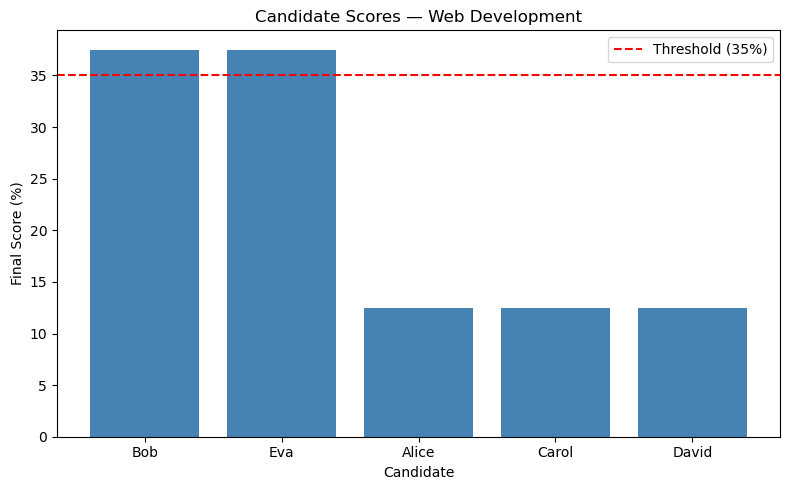

In [20]:
import matplotlib.pyplot as plt

# Chart 1: Final Score for each candidate
plt.figure(figsize=(8, 5))
plt.bar(results_df['Candidate'], results_df['Final Score'], color='steelblue')
plt.axhline(y=THRESHOLD, color='red', linestyle='--', label=f'Threshold ({THRESHOLD}%)')
plt.title(f'Candidate Scores — {TARGET_ROLE}')
plt.xlabel('Candidate')
plt.ylabel('Final Score (%)')
plt.legend()
plt.tight_layout()

plt.show()


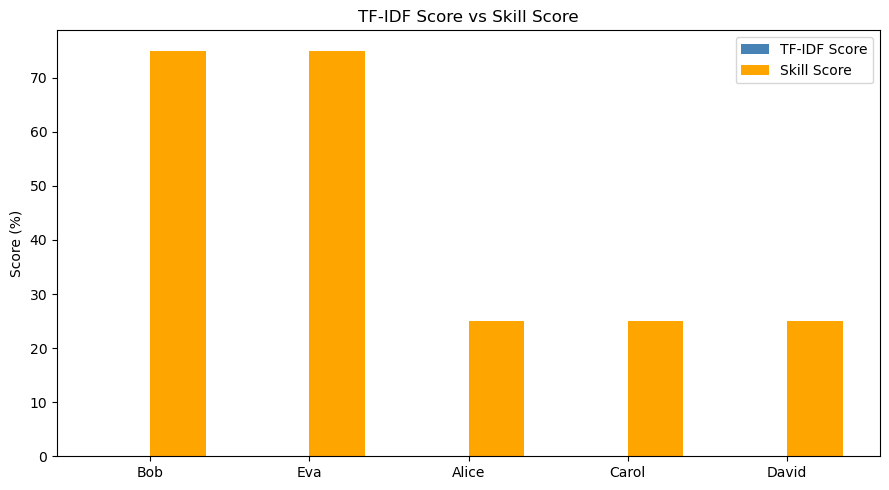

In [21]:
# Chart 2: TF-IDF vs Skill Score comparison
import numpy as np

x = np.arange(len(results_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, results_df['TF-IDF Score'], width, label='TF-IDF Score', color='steelblue')
plt.bar(x + width/2, results_df['Skill Score'],  width, label='Skill Score',  color='orange')
plt.xticks(x, results_df['Candidate'])
plt.title('TF-IDF Score vs Skill Score')
plt.ylabel('Score (%)')
plt.legend()
plt.tight_layout()

plt.show()


In [22]:
import pickle

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# Save the results dataframe
with open('results.pkl', 'wb') as f:
    pickle.dump(results_df, f)

# Save the required skills list
with open('required_skills.pkl', 'wb') as f:
    pickle.dump(required_skills, f)

print("Saved: tfidf_vectorizer.pkl")
print("Saved: results.pkl")
print("Saved: required_skills.pkl")

Saved: tfidf_vectorizer.pkl
Saved: results.pkl
Saved: required_skills.pkl


This project demonstrates how **classical NLP techniques** (TF-IDF + Cosine Similarity +
Regex skill extraction) can be combined into a practical, interpretable, and deployable
resume screening tool — without requiring any labelled training data, GPU hardware,
or paid APIs.

The entire pipeline runs **in-memory on every request**, making it stateless, scalable,
and easy to deploy on platforms like Streamlit Cloud.